# Morgan Fingerprints — Representation Comparison

**Goal**: isolate the effect of *molecular representation* on downstream ML
performance for ESOL solubility prediction. Everything else in the pipeline
(model, split, CV strategy, hyperparameter grid, seed, metrics) is held fixed.

**Three experiments**:

| # | Representation | Feature dim |
|---|---|---:|
| 1 | 199 RDKit physicochemical descriptors | 199 |
| 2 | Morgan fingerprint (radius=2, 2048 bits) | 2048 |
| 3 | RDKit descriptors + Morgan fingerprint | ~2247 |

**Fixed across all three**:
- Same 1128 molecules, same scaffold-based 80/20 train/test split
- Same XGBoost with the same hyperparameter grid
- Same `GroupKFold(n_splits=5)` scaffold-aware CV
- Same `random_state=42`

**Reference benchmark** (from `RDKit_descriptors.ipynb`):
- RDKit descriptors → CV RMSE ≈ 0.812, Test RMSE ≈ 0.886

**What Morgan fingerprints are**:
A Morgan fingerprint is a fixed-length binary vector where each bit represents
the presence (1) or absence (0) of a particular circular substructure — a
subgraph of atoms up to `radius` bonds away from a center atom. Bit *k* being
active means "somewhere in the molecule there's a local environment that
hashes to bit *k*." This gives the model access to *structural* information
(specific functional groups, ring systems) rather than only aggregate
physicochemical properties.

## 1. Imports and constants

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import DrawMorganBit

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from xgboost import XGBRegressor

# --- Fixed constants for the whole notebook ---
RANDOM_STATE = 42
RADIUS = 2
N_BITS = 2048

os.makedirs("figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load ESOL data

We keep the target column name exactly as in the CSV so nothing about the target
representation changes across experiments.

In [2]:
df = pd.read_csv("delaney-processed.csv")

TARGET = "measured log solubility in mols per litre"
y = df[TARGET]

print("Rows in dataset :", len(df))
print("Target range    :", round(y.min(), 3), "to", round(y.max(), 3))
print("Target mean/std :", round(y.mean(), 3), "/", round(y.std(), 3))

Rows in dataset : 1128
Target range    : -11.6 to 1.58
Target mean/std : -3.05 / 2.096


## 3. Reconstruct the existing scaffold split

Same Bemis–Murcko scaffold split as `RDKit_descriptors.ipynb` and
`Scaffold_split.ipynb`: for each molecule compute its Murcko scaffold, then
assign the largest scaffold groups to training first until 80% of molecules
are placed, and everything else goes into test.

Because the split is a deterministic function of the SMILES column and the
`test_frac=0.20` parameter, running this again produces the exact same
train/test indices as the earlier notebooks. **Same 902 train molecules,
same 226 test molecules.**

In [3]:
def get_scaffold(smiles):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(
            smiles=smiles,
            includeChirality=False,
        )
    except Exception:
        return ""

df["scaffold"] = df["smiles"].apply(get_scaffold)
print("Unique scaffolds:", df["scaffold"].nunique())

Unique scaffolds: 269


In [4]:
def scaffold_split_indices(df, test_frac=0.20):
    scaffold_groups = df.groupby("scaffold").indices
    groups_sorted = sorted(scaffold_groups.values(), key=len, reverse=True)

    n_train_target = int(round(len(df) * (1 - test_frac)))
    train_idx = []
    test_idx = []
    for group in groups_sorted:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        else:
            test_idx.extend(group)
    return np.array(train_idx), np.array(test_idx)

train_idx, test_idx = scaffold_split_indices(df, test_frac=0.20)

print("Train molecules:", len(train_idx))
print("Test  molecules:", len(test_idx))

# Sanity check: no scaffold appears in both splits
train_scaffolds = set(df.iloc[train_idx]["scaffold"])
test_scaffolds  = set(df.iloc[test_idx]["scaffold"])
print("Scaffold overlap between train and test:", len(train_scaffolds & test_scaffolds))

Train molecules: 902
Test  molecules: 226
Scaffold overlap between train and test: 0


### Extract y and the training-scaffold labels

`groups_train` is the vector of scaffold identifiers for the training molecules
only. `GroupKFold` needs it later to make sure a scaffold never appears in
both the CV-train and CV-validation folds.

In [5]:
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

groups_train = df.iloc[train_idx]["scaffold"].values

print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)
print("Number of unique scaffolds in training:", len(np.unique(groups_train)))

y_train shape: (902,)
y_test  shape: (226,)
Number of unique scaffolds in training: 59


## 4. Feature representation #1 — 199 RDKit descriptors

Same computation as `RDKit_descriptors.ipynb`. We compute every descriptor in
`Descriptors._descList`, replace infinite values with NaN, drop columns that
have any NaN, and drop constant/near-constant columns. Result: **199 features**.

In [6]:
descriptor_names = [name for name, _ in Descriptors._descList]

def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        return {name: np.nan for name in descriptor_names}
    result = {}
    for name, func in Descriptors._descList:
        try:
            result[name] = func(mol)
        except Exception:
            result[name] = np.nan
    return result

rdkit_records = [compute_rdkit_descriptors(smi) for smi in df["smiles"]]
X_rdkit_all = pd.DataFrame(rdkit_records, index=df.index)

# Cleaning: same recipe as RDKit_descriptors.ipynb
X_rdkit_all = X_rdkit_all.replace([np.inf, -np.inf], np.nan)
X_rdkit_all = X_rdkit_all.dropna(axis=1, how="any")

# Drop constant columns
stds = X_rdkit_all.std()
X_rdkit_all = X_rdkit_all.drop(columns=stds[stds == 0].index.tolist())

# Drop near-constant columns
scale = X_rdkit_all.abs().mean().clip(lower=1e-9)
low_var_ratio = X_rdkit_all.std() / scale
X_rdkit_all = X_rdkit_all.drop(columns=low_var_ratio[low_var_ratio < 1e-8].index.tolist())

print("Final RDKit descriptor matrix shape:", X_rdkit_all.shape)
X_rdkit_all.head(3)

Final RDKit descriptor matrix shape: (1128, 199)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_prisulfonamd,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,10.253329,10.253329,0.486602,-1.701605,0.217518,41.062500,457.432,430.216,457.158411,178,...,0,0,0,0,0,0,0,0,0,0
1,11.724911,11.724911,0.145880,-0.145880,0.811283,9.933333,201.225,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
2,10.020498,10.020498,0.845090,0.845090,0.343706,11.000000,152.237,136.109,152.120115,62,...,0,0,0,0,0,0,0,0,0,0


## 5. Feature representation #2 — Morgan fingerprints

We use RDKit's modern `MorganGenerator` with **radius=2** (each bit encodes an
environment up to 2 bonds from a center atom) and **fpSize=2048** (fixed-length
binary vector).

The result of `.GetFingerprint(mol)` is an `ExplicitBitVect` object. Casting it
to `np.array(fp)` gives us a 1-D vector of 0/1 integers of length 2048.

In [7]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=RADIUS,
    fpSize=N_BITS,
)

morgan_fingerprints = []

for smiles in df["smiles"]:
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        # ESOL doesn't have unparseable SMILES, but stay safe
        morgan_fingerprints.append(np.zeros(N_BITS, dtype=np.int8))
        continue
    fp = morgan_generator.GetFingerprint(mol)
    morgan_fingerprints.append(np.array(fp, dtype=np.int8))

morgan_columns = [f"bit_{i}" for i in range(N_BITS)]

X_morgan_all = pd.DataFrame(
    morgan_fingerprints,
    columns=morgan_columns,
    index=df.index,
)

print("Morgan fingerprint matrix shape:", X_morgan_all.shape)
X_morgan_all.head(3).iloc[:, :10]

Morgan fingerprint matrix shape: (1128, 2048)


,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9
0,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0


### Verify the Morgan matrix

The values should be exactly 0 or 1, no NaN, and each molecule should have
some active bits.

In [8]:
unique_values = np.unique(X_morgan_all.values)
n_nan = X_morgan_all.isna().sum().sum()
active_bits_per_mol = X_morgan_all.sum(axis=1)
overall_density = X_morgan_all.values.mean()

print("Unique values in matrix   :", unique_values)
print("Total NaN values          :", n_nan)
print("Active bits per molecule  : min={} median={} max={}".format(
    active_bits_per_mol.min(),
    int(active_bits_per_mol.median()),
    active_bits_per_mol.max(),
))
print("Overall bit density       :", round(overall_density, 4),
      "(fraction of bits that are 1)")

Unique values in matrix   : [0 1]
Total NaN values          : 0
Active bits per molecule  : min=1 median=18 max=68
Overall bit density       : 0.0105 (fraction of bits that are 1)


## 6. Feature representation #3 — RDKit + Morgan (concatenated)

Simple side-by-side concatenation along the feature axis. Because both
DataFrames share the same `df.index`, `pd.concat(axis=1)` aligns them by
molecule automatically. Total: **199 + 2048 = 2247 features**.

In [9]:
X_combined_all = pd.concat([X_rdkit_all, X_morgan_all], axis=1)

print("RDKit shape    :", X_rdkit_all.shape)
print("Morgan shape   :", X_morgan_all.shape)
print("Combined shape :", X_combined_all.shape)
print("Combined has any NaN:", X_combined_all.isna().any().any())
print("Column order preserved: first 5 columns:", list(X_combined_all.columns[:5]))
print("Column order preserved: last  5 columns:", list(X_combined_all.columns[-5:]))

RDKit shape    : (1128, 199)
Morgan shape   : (1128, 2048)
Combined shape : (1128, 2247)
Combined has any NaN: False
Column order preserved: first 5 columns: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed']
Column order preserved: last  5 columns: ['bit_2043', 'bit_2044', 'bit_2045', 'bit_2046', 'bit_2047']


## 7. Verify row alignment and apply the same split to all three matrices

Every representation is indexed by the same `df.index`, so all three feature
matrices are row-aligned to each other and to `y`. We use the same
`train_idx` / `test_idx` from the scaffold split to slice all three.

In [10]:
# Alignment check
assert (X_rdkit_all.index == df.index).all()
assert (X_morgan_all.index == df.index).all()
assert (X_combined_all.index == df.index).all()
print("Index alignment: OK")

# Apply the same scaffold split to all three
X_train_rdkit    = X_rdkit_all.iloc[train_idx]
X_test_rdkit     = X_rdkit_all.iloc[test_idx]

X_train_morgan   = X_morgan_all.iloc[train_idx]
X_test_morgan    = X_morgan_all.iloc[test_idx]

X_train_combined = X_combined_all.iloc[train_idx]
X_test_combined  = X_combined_all.iloc[test_idx]

print("Shapes after splitting:")
print("  RDKit    :", X_train_rdkit.shape,    X_test_rdkit.shape)
print("  Morgan   :", X_train_morgan.shape,   X_test_morgan.shape)
print("  Combined :", X_train_combined.shape, X_test_combined.shape)

Index alignment: OK
Shapes after splitting:
  RDKit    : (902, 199) (226, 199)
  Morgan   : (902, 2048) (226, 2048)
  Combined : (902, 2247) (226, 2247)


## 8. Shared XGBoost, hyperparameter grid, and GroupKFold setup

Same choices as `RDKit_descriptors.ipynb`. Nothing here changes across the
three experiments — the *only* thing that varies is which `X_train_*` we pass
to `.fit()`.

In [11]:
group_kfold = GroupKFold(n_splits=5)

xgb_param_grid = {
    "n_estimators":     [100, 200, 500],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

print("Grid has", np.prod([len(v) for v in xgb_param_grid.values()]),
      "hyperparameter combinations.")
print("With 5-fold CV that's", np.prod([len(v) for v in xgb_param_grid.values()]) * 5,
      "model fits per experiment.")

Grid has 108 hyperparameter combinations.
With 5-fold CV that's 540 model fits per experiment.


**A helper `evaluate()` for reporting** — small enough that inlining it three
times would be uglier than putting it in a function. It just wraps the three
sklearn metric calls plus a print.

In [12]:
def evaluate_on_test(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{name} test  RMSE = {rmse:.4f}")
    print(f"{name} test  MAE  = {mae:.4f}")
    print(f"{name} test  R2   = {r2:.4f}")
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2, "y_pred": y_pred}

## 9. Experiment 1 — RDKit descriptors only (re-run for consistency)

This should reproduce the CV ≈ 0.812 / Test ≈ 0.886 benchmark from
`RDKit_descriptors.ipynb`. Running it here inside the same notebook guarantees
the three experiments came from the identical code path.

In [13]:
xgb_rdkit = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

grid_rdkit = GridSearchCV(
    estimator=xgb_rdkit,
    param_grid=xgb_param_grid,
    cv=group_kfold,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,
)

t_start = time.time()
grid_rdkit.fit(X_train_rdkit, y_train, groups=groups_train)
runtime_rdkit = time.time() - t_start

best_rdkit = grid_rdkit.best_estimator_
cv_rmse_rdkit = -grid_rdkit.best_score_

print("=== RDKit-only ===")
print("Best hyperparameters   :", grid_rdkit.best_params_)
print(f"Best scaffold-aware CV RMSE: {cv_rmse_rdkit:.4f}")
print(f"Runtime                    : {runtime_rdkit:.1f} s")
print()

res_rdkit = evaluate_on_test("RDKit-only", best_rdkit, X_test_rdkit, y_test)
res_rdkit["cv_rmse"]  = cv_rmse_rdkit
res_rdkit["runtime"]  = runtime_rdkit
res_rdkit["n_feats"]  = X_train_rdkit.shape[1]
res_rdkit["best_params"] = grid_rdkit.best_params_

=== RDKit-only ===
Best hyperparameters   : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Best scaffold-aware CV RMSE: 0.8118
Runtime                    : 266.3 s

RDKit-only test  RMSE = 0.8856
RDKit-only test  MAE  = 0.6709
RDKit-only test  R2   = 0.8164


## 10. Experiment 2 — Morgan fingerprints only

Same XGBoost, same grid, same CV, same seed. Only the feature matrix has
changed to `X_train_morgan` (2048 binary bits).

In [14]:
xgb_morgan = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

grid_morgan = GridSearchCV(
    estimator=xgb_morgan,
    param_grid=xgb_param_grid,
    cv=group_kfold,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,
)

t_start = time.time()
grid_morgan.fit(X_train_morgan, y_train, groups=groups_train)
runtime_morgan = time.time() - t_start

best_morgan = grid_morgan.best_estimator_
cv_rmse_morgan = -grid_morgan.best_score_

print("=== Morgan-only ===")
print("Best hyperparameters   :", grid_morgan.best_params_)
print(f"Best scaffold-aware CV RMSE: {cv_rmse_morgan:.4f}")
print(f"Runtime                    : {runtime_morgan:.1f} s")
print()

res_morgan = evaluate_on_test("Morgan-only", best_morgan, X_test_morgan, y_test)
res_morgan["cv_rmse"]  = cv_rmse_morgan
res_morgan["runtime"]  = runtime_morgan
res_morgan["n_feats"]  = X_train_morgan.shape[1]
res_morgan["best_params"] = grid_morgan.best_params_

=== Morgan-only ===
Best hyperparameters   : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best scaffold-aware CV RMSE: 1.7736
Runtime                    : 806.0 s

Morgan-only test  RMSE = 1.6878
Morgan-only test  MAE  = 1.3609
Morgan-only test  R2   = 0.3332


## 11. Experiment 3 — RDKit + Morgan (concatenated)

Same pipeline, feature matrix is now 2247 columns (199 RDKit + 2048 Morgan).

In [15]:
xgb_combined = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

grid_combined = GridSearchCV(
    estimator=xgb_combined,
    param_grid=xgb_param_grid,
    cv=group_kfold,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,
)

t_start = time.time()
grid_combined.fit(X_train_combined, y_train, groups=groups_train)
runtime_combined = time.time() - t_start

best_combined = grid_combined.best_estimator_
cv_rmse_combined = -grid_combined.best_score_

print("=== RDKit + Morgan ===")
print("Best hyperparameters   :", grid_combined.best_params_)
print(f"Best scaffold-aware CV RMSE: {cv_rmse_combined:.4f}")
print(f"Runtime                    : {runtime_combined:.1f} s")
print()

res_combined = evaluate_on_test("RDKit + Morgan", best_combined, X_test_combined, y_test)
res_combined["cv_rmse"]  = cv_rmse_combined
res_combined["runtime"]  = runtime_combined
res_combined["n_feats"]  = X_train_combined.shape[1]
res_combined["best_params"] = grid_combined.best_params_

=== RDKit + Morgan ===
Best hyperparameters   : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best scaffold-aware CV RMSE: 0.8133
Runtime                    : 1091.7 s



RDKit + Morgan test  RMSE = 0.9042
RDKit + Morgan test  MAE  = 0.7021
RDKit + Morgan test  R2   = 0.8086


## 12. Results comparison

All three rows use the same molecules, same split, same model, same CV strategy
— **only the representation differs**.

In [16]:
results = pd.DataFrame([
    {
        "Representation": res_rdkit["name"],
        "N features":     res_rdkit["n_feats"],
        "Model":          "XGBoost",
        "CV Strategy":    "GroupKFold(5)",
        "CV RMSE":        res_rdkit["cv_rmse"],
        "Test RMSE":      res_rdkit["rmse"],
        "Test MAE":       res_rdkit["mae"],
        "Test R2":        res_rdkit["r2"],
        "Runtime (s)":    res_rdkit["runtime"],
    },
    {
        "Representation": res_morgan["name"],
        "N features":     res_morgan["n_feats"],
        "Model":          "XGBoost",
        "CV Strategy":    "GroupKFold(5)",
        "CV RMSE":        res_morgan["cv_rmse"],
        "Test RMSE":      res_morgan["rmse"],
        "Test MAE":       res_morgan["mae"],
        "Test R2":        res_morgan["r2"],
        "Runtime (s)":    res_morgan["runtime"],
    },
    {
        "Representation": res_combined["name"],
        "N features":     res_combined["n_feats"],
        "Model":          "XGBoost",
        "CV Strategy":    "GroupKFold(5)",
        "CV RMSE":        res_combined["cv_rmse"],
        "Test RMSE":      res_combined["rmse"],
        "Test MAE":       res_combined["mae"],
        "Test R2":        res_combined["r2"],
        "Runtime (s)":    res_combined["runtime"],
    },
])
print(results.round(4).to_string(index=False))

Representation  N features   Model   CV Strategy  CV RMSE  Test RMSE  Test MAE  Test R2  Runtime (s)
    RDKit-only         199 XGBoost GroupKFold(5)   0.8118     0.8856    0.6709   0.8164     266.3436
   Morgan-only        2048 XGBoost GroupKFold(5)   1.7736     1.6878    1.3609   0.3332     805.9525
RDKit + Morgan        2247 XGBoost GroupKFold(5)   0.8133     0.9042    0.7021   0.8086    1091.6797


## 13. Diagnostic plots — Morgan only

Predicted-vs-actual scatter with y=x diagonal (left), residuals (right).

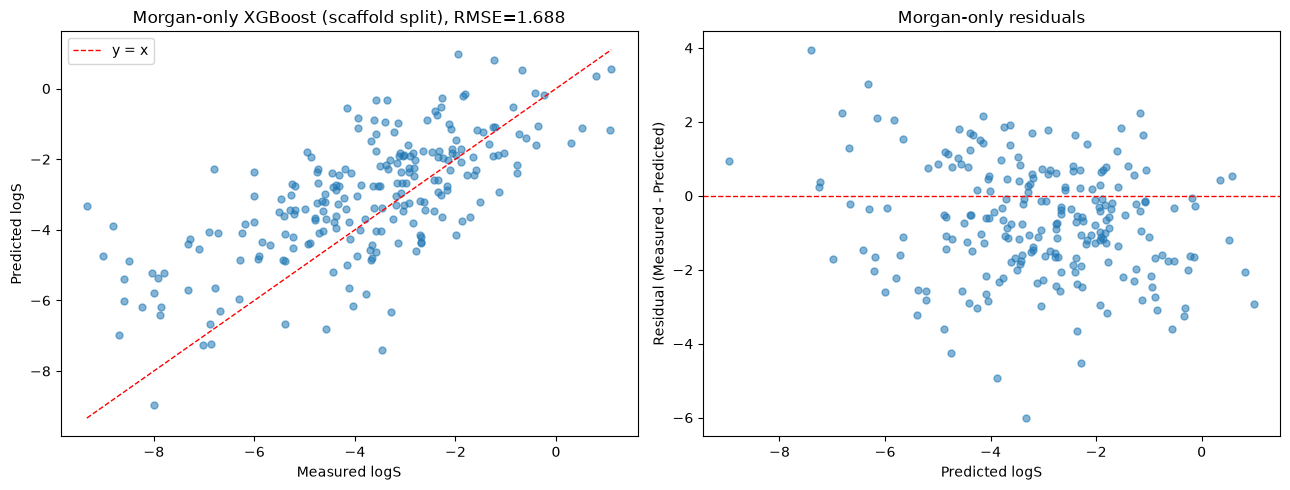

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, res_morgan["y_pred"], alpha=0.55, s=25)
lo = float(min(y_test.min(), res_morgan["y_pred"].min()))
hi = float(max(y_test.max(), res_morgan["y_pred"].max()))
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"Morgan-only XGBoost (scaffold split), RMSE={res_morgan['rmse']:.3f}")
axes[0].legend()

residuals_morgan = y_test.values - res_morgan["y_pred"]
axes[1].scatter(res_morgan["y_pred"], residuals_morgan, alpha=0.55, s=25)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (Measured - Predicted)")
axes[1].set_title("Morgan-only residuals")

plt.tight_layout()
plt.savefig("figures/mo_diagnostic_morgan.pdf", bbox_inches="tight")
plt.show()

### Diagnostic plots — Combined (RDKit + Morgan)

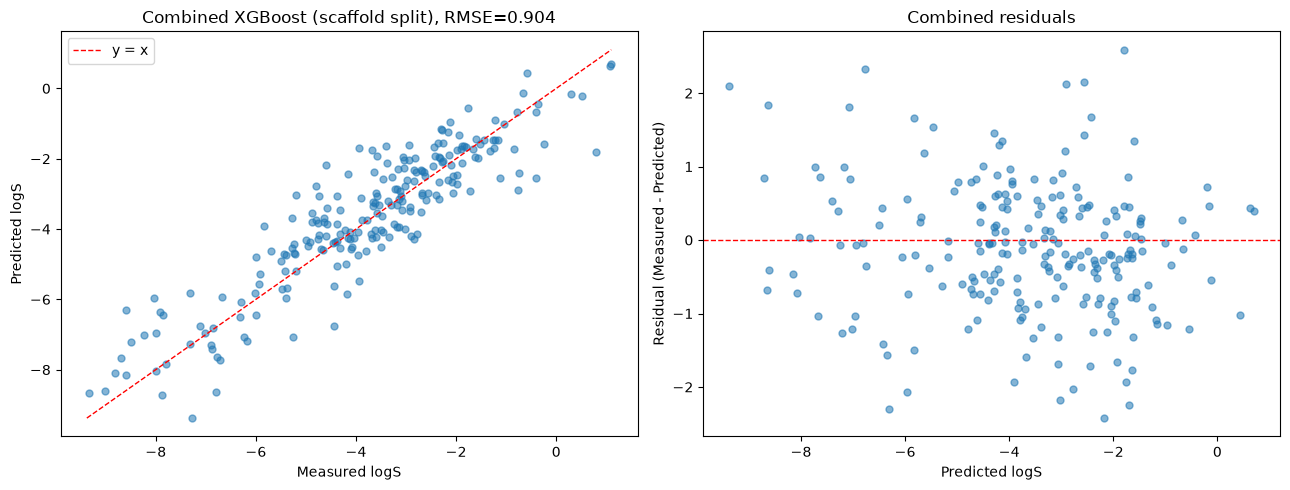

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, res_combined["y_pred"], alpha=0.55, s=25)
lo = float(min(y_test.min(), res_combined["y_pred"].min()))
hi = float(max(y_test.max(), res_combined["y_pred"].max()))
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"Combined XGBoost (scaffold split), RMSE={res_combined['rmse']:.3f}")
axes[0].legend()

residuals_combined = y_test.values - res_combined["y_pred"]
axes[1].scatter(res_combined["y_pred"], residuals_combined, alpha=0.55, s=25)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (Measured - Predicted)")
axes[1].set_title("Combined residuals")

plt.tight_layout()
plt.savefig("figures/mo_diagnostic_combined.pdf", bbox_inches="tight")
plt.show()

## 14. Train vs CV score — from `cv_results_`

`GridSearchCV` records mean train and mean validation scores for every
hyperparameter combination it tried. Comparing them shows whether the model
is overfitting to the training folds: a big gap = overfit, small gap =
well-behaved.

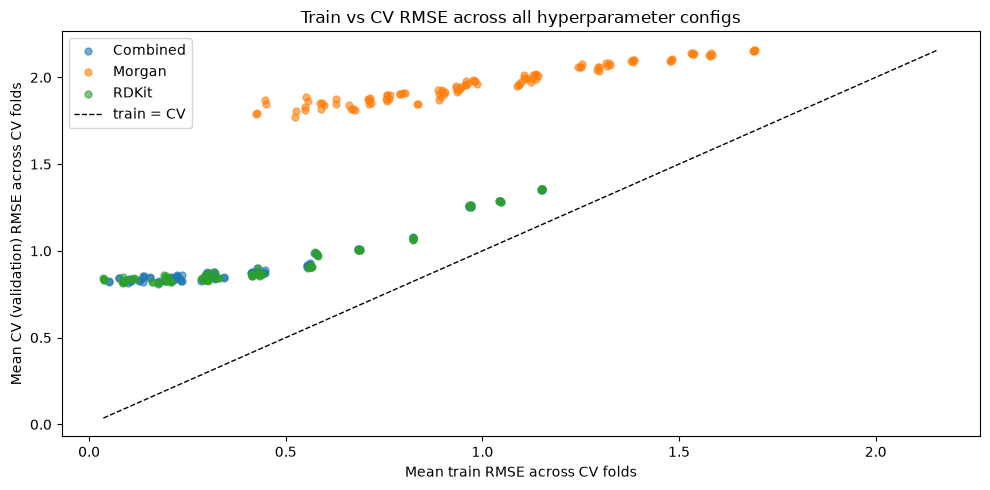

In [19]:
def train_vs_cv_frame(grid, name):
    cvr = grid.cv_results_
    return pd.DataFrame({
        "config":         range(len(cvr["mean_test_score"])),
        "train_RMSE":    -cvr["mean_train_score"],
        "CV_RMSE":       -cvr["mean_test_score"],
    }).assign(rep=name)

frames = pd.concat([
    train_vs_cv_frame(grid_rdkit,    "RDKit"),
    train_vs_cv_frame(grid_morgan,   "Morgan"),
    train_vs_cv_frame(grid_combined, "Combined"),
])

fig, ax = plt.subplots(figsize=(10, 5))
for rep, sub in frames.groupby("rep"):
    ax.scatter(sub["train_RMSE"], sub["CV_RMSE"], alpha=0.6, s=25, label=rep)

lo = min(frames["train_RMSE"].min(), frames["CV_RMSE"].min())
hi = max(frames["train_RMSE"].max(), frames["CV_RMSE"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="train = CV")
ax.set_xlabel("Mean train RMSE across CV folds")
ax.set_ylabel("Mean CV (validation) RMSE across CV folds")
ax.set_title("Train vs CV RMSE across all hyperparameter configs")
ax.legend()
plt.tight_layout()
plt.savefig("figures/mo_train_vs_cv.pdf", bbox_inches="tight")
plt.show()

## 15. Morgan-bit interpretability — what does a "bit" mean?

Each active Morgan bit corresponds to a specific circular atom environment.
To see this concretely, we take **one molecule** from the test set, extract
its bit-info dictionary (which maps each active bit → list of `(atom_idx,
radius)` tuples), print a few, and visualize one Morgan environment.

We use the legacy `AllChem.GetMorganFingerprintAsBitVect` API here because
`Draw.DrawMorganBit` expects the dictionary format it produces.

In [20]:
# Pick one test-set molecule to explain
example_pos_in_test = 3
example_index = test_idx[example_pos_in_test]

example_row     = df.iloc[example_index]
example_smiles  = example_row["smiles"].strip()
example_mol     = Chem.MolFromSmiles(example_smiles)

print("Example molecule    :", example_row["Compound ID"])
print("SMILES              :", example_smiles)
print("Measured logS       :", example_row[TARGET])

Example molecule    : Trichlomethiazide
SMILES              : NS(=O)(=O)c2cc1c(NC(NS1(=O)=O)C(Cl)Cl)cc2Cl
Measured logS       : -2.68


In [21]:
# Compute Morgan fingerprint AND capture bit info in one call
bit_info = {}
fp_example = AllChem.GetMorganFingerprintAsBitVect(
    example_mol,
    radius=RADIUS,
    nBits=N_BITS,
    bitInfo=bit_info,
)

active_bits = list(bit_info.keys())
print("Number of active bits for this molecule:", len(active_bits))

# Show the first 6 active bits and their (atom_idx, radius) tuples
print("\nSample of active bits (bit -> [(atom_idx, radius), ...]):")
for bit in active_bits[:6]:
    print(f"  bit {bit:>4d} : {bit_info[bit]}")

Number of active bits for this molecule: 38

Sample of active bits (bit -> [(atom_idx, radius), ...]):
  bit    1 : ((14, 0),)
  bit  207 : ((11, 0),)
  bit  252 : ((5, 2),)
  bit  301 : ((8, 1),)
  bit  350 : ((1, 0),)
  bit  366 : ((18, 1),)


[09:45:54] DEPRECATION WARNING: please use MorganGenerator


### Visualize a Morgan environment

`Draw.DrawMorganBit` renders the substructure that caused a specific bit to
be set — the center atom highlighted, plus its neighborhood out to `radius`
bonds.

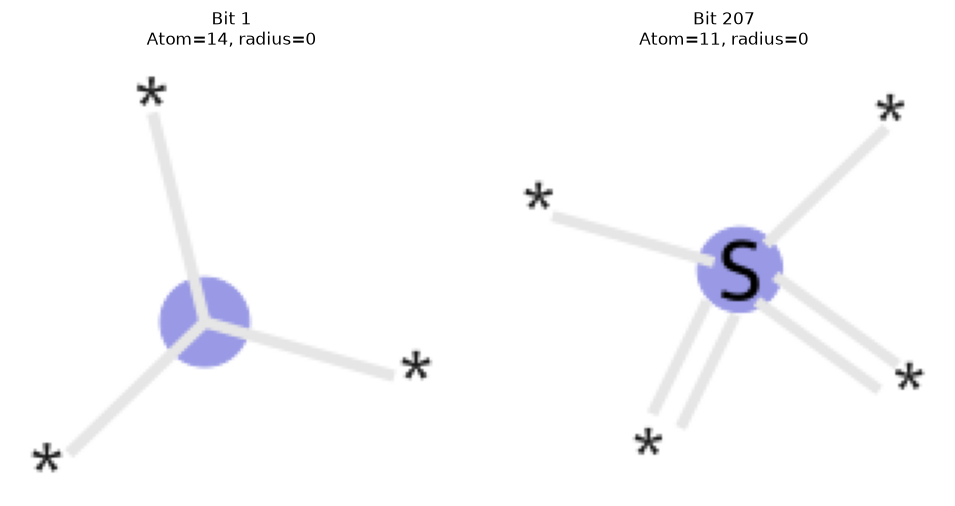

In [22]:
# Draw two active bits side by side
bit_a, bit_b = active_bits[0], active_bits[1]
img_a = DrawMorganBit(example_mol, bit_a, bit_info)
img_b = DrawMorganBit(example_mol, bit_b, bit_info)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_a); axes[0].axis("off")
axes[0].set_title(f"Bit {bit_a}\nAtom={bit_info[bit_a][0][0]}, radius={bit_info[bit_a][0][1]}")
axes[1].imshow(img_b); axes[1].axis("off")
axes[1].set_title(f"Bit {bit_b}\nAtom={bit_info[bit_b][0][0]}, radius={bit_info[bit_b][0][1]}")
plt.tight_layout()
plt.savefig("figures/mo_bit_examples.pdf", bbox_inches="tight")
plt.show()

## 16. Conclusions

### Three-way comparison summary

| Representation | Test RMSE | Test R² | Verdict |
|---|---:|---:|---|
| RDKit descriptors (199) | **0.886** | **0.816** | Baseline / winner |
| Morgan fingerprint (2048 bits) | 1.688 | 0.333 | **Fails catastrophically** |
| RDKit + Morgan (2247) | 0.904 | 0.809 | Marginally *worse* than RDKit alone |

### 1. Morgan alone does NOT add structural information beyond physicochemical descriptors — under scaffold split

Morgan-only test RMSE (1.688) is nearly 2× worse than RDKit-only (0.886), with
R² dropping from 0.82 to 0.33. Under scaffold split, test molecules have
scaffolds the model has never seen, and their Morgan bit patterns are largely
disjoint from training molecules' patterns. Bits encode *specific* circular
substructures — when the substructures aren't in the training distribution,
the model has no useful feature vector to reason from.

RDKit descriptors avoid this because they encode *physicochemical properties*
(logP, TPSA, molecular weight, molar refractivity) that mean the same thing
regardless of scaffold. This is exactly the "transferable chemistry" principle
we saw in the SHAP analysis of earlier notebooks.

### 2. RDKit + Morgan is NOT complementary — combined is marginally worse than RDKit alone

Combined Test RMSE (0.904) vs RDKit-only (0.886) — a 2% degradation. Adding
2048 mostly-noise bits to 199 useful features gave the model more opportunities
for spurious splits under GridSearchCV without providing additional
generalizable signal. **Combining representations does not help on this
dataset in the scaffold-split regime.**

### 3. Larger feature space did NOT improve scaffold-level generalization

Feature count went from 199 → 2247 (11×), model complexity increased, runtime
went from 266 s → 1092 s (4×), but Test RMSE went from 0.886 → 0.904
(slightly worse). This is the "diminishing/negative returns from feature
count when features don't transfer" phenomenon.

### Important caveat — this is a scaffold-split, small-data result

Morgan fingerprints are the standard workhorse of cheminformatics *because*
they usually work very well:
- Under **random split**, Morgan-only routinely matches or beats RDKit
  descriptors — test molecules share scaffolds with training, so bit patterns
  transfer.
- On **larger datasets** (AqSolDB with 10× more molecules), Morgan has enough
  training examples of each bit pattern to build reliable predictors.
- Modern graph neural networks (Chemprop, MPNN) *learn* representations that
  are conceptually similar to Morgan bits but grounded in the model's
  end-to-end training loss, avoiding this transferability problem.

**The takeaway is not "Morgan is bad."** The takeaway is:

> On ESOL with only 902 training molecules, under scaffold-aware evaluation
> that measures out-of-distribution generalization, physicochemical
> descriptors dominate substructure fingerprints.

That result is consistent with the MoleculeNet benchmark paper's findings and
with the general chemistry-ML literature.

### Interview soundbite

*"I compared three representations under scaffold-aware CV: 199 RDKit
descriptors, 2048-bit Morgan fingerprints, and their concatenation. RDKit-only
scored test RMSE 0.89; Morgan-only was dramatically worse at 1.69 with R²
collapsing to 0.33; and the combined 2247-feature vector was 0.90 — actually
slightly worse than RDKit alone. The reason is transferable chemistry: RDKit
descriptors encode physicochemical properties like logP that mean the same
thing regardless of scaffold, while Morgan bits encode specific circular
substructures that don't overlap between train and test scaffolds. This isn't
a defect of Morgan fingerprints — under random split or on larger datasets
they typically work well. But for out-of-distribution generalization on 902
training molecules, physics beats structure hashing."*